# City-wide Forecast Visualizations

Presentation-oriented figures for the selected city-wide model. Forecasting logic is imported from `src/citywide_forecasting.py`.

## 1. Imports and plot configuration

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.citywide_forecasting import (
    fit_nb,
    hybrid_forecast,
    prepare_actual_year,
    prepare_daily_data,
    recursive_forecast,
)

DATA_PATH = PROJECT_ROOT / "data" / "requests.csv"
ACTUAL_2026_PATH = PROJECT_ROOT / "data" / "2026requests.csv"

ISSUE_TYPE = "garbage"
MODEL_NAME = "nb_recent3_lag7"
TREND_MODE = "log"
LOG_TREND_DIVISOR = 3
INCLUDE_HOLIDAYS = True

HISTORY_PLOT_START_YEAR = 2024
FORECAST_YEAR = 2026
FORECAST_END = "2026-12-31"

HISTORY_LINEWIDTH = 2.2
FORECAST_LINEWIDTH = 2.8

## 2. Prepare data and forecasts

In [2]:
raw_history = pd.read_csv(DATA_PATH)
raw_2026 = pd.read_csv(ACTUAL_2026_PATH)

history = prepare_daily_data(
    raw_history,
    issue_type=ISSUE_TYPE,
    start_year=2020,
    end_year=2025,
    log_divisor=LOG_TREND_DIVISOR,
)

actual_2026 = prepare_actual_year(
    raw_2026,
    FORECAST_YEAR,
    issue_type=ISSUE_TYPE,
)

model = fit_nb(
    history,
    model_name=MODEL_NAME,
    trend_mode=TREND_MODE,
    include_holidays=INCLUDE_HOLIDAYS,
)

origin = history["reported"].min()

fully_recursive = recursive_forecast(
    model,
    history[["reported", "reports"]],
    pd.date_range(f"{FORECAST_YEAR}-01-01", FORECAST_END, freq="D"),
    origin=origin,
    log_divisor=LOG_TREND_DIVISOR,
)

hybrid_full, daily_updated, recursive_future = hybrid_forecast(
    model,
    history[["reported", "reports"]],
    actual_2026,
    FORECAST_END,
    origin=origin,
    log_divisor=LOG_TREND_DIVISOR,
)

history_plot = history[
    history["reported"].dt.year >= HISTORY_PLOT_START_YEAR
][["reported", "reports"]].copy()

last_actual = actual_2026["reported"].max()

print(f"Model: {MODEL_NAME}")
print(f"Trend: {TREND_MODE} | divisor={LOG_TREND_DIVISOR}")
print(f"Last available actual: {last_actual.date()}")

Model: nb_recent3_lag7
Trend: log | divisor=3
Last available actual: 2026-06-08


## 3. Main three-graph layout

Top-left is a pure long-range forecast from the end of 2025. Top-right uses real daily updates while available, then switches to recursion. The bottom graph contains only real observations.

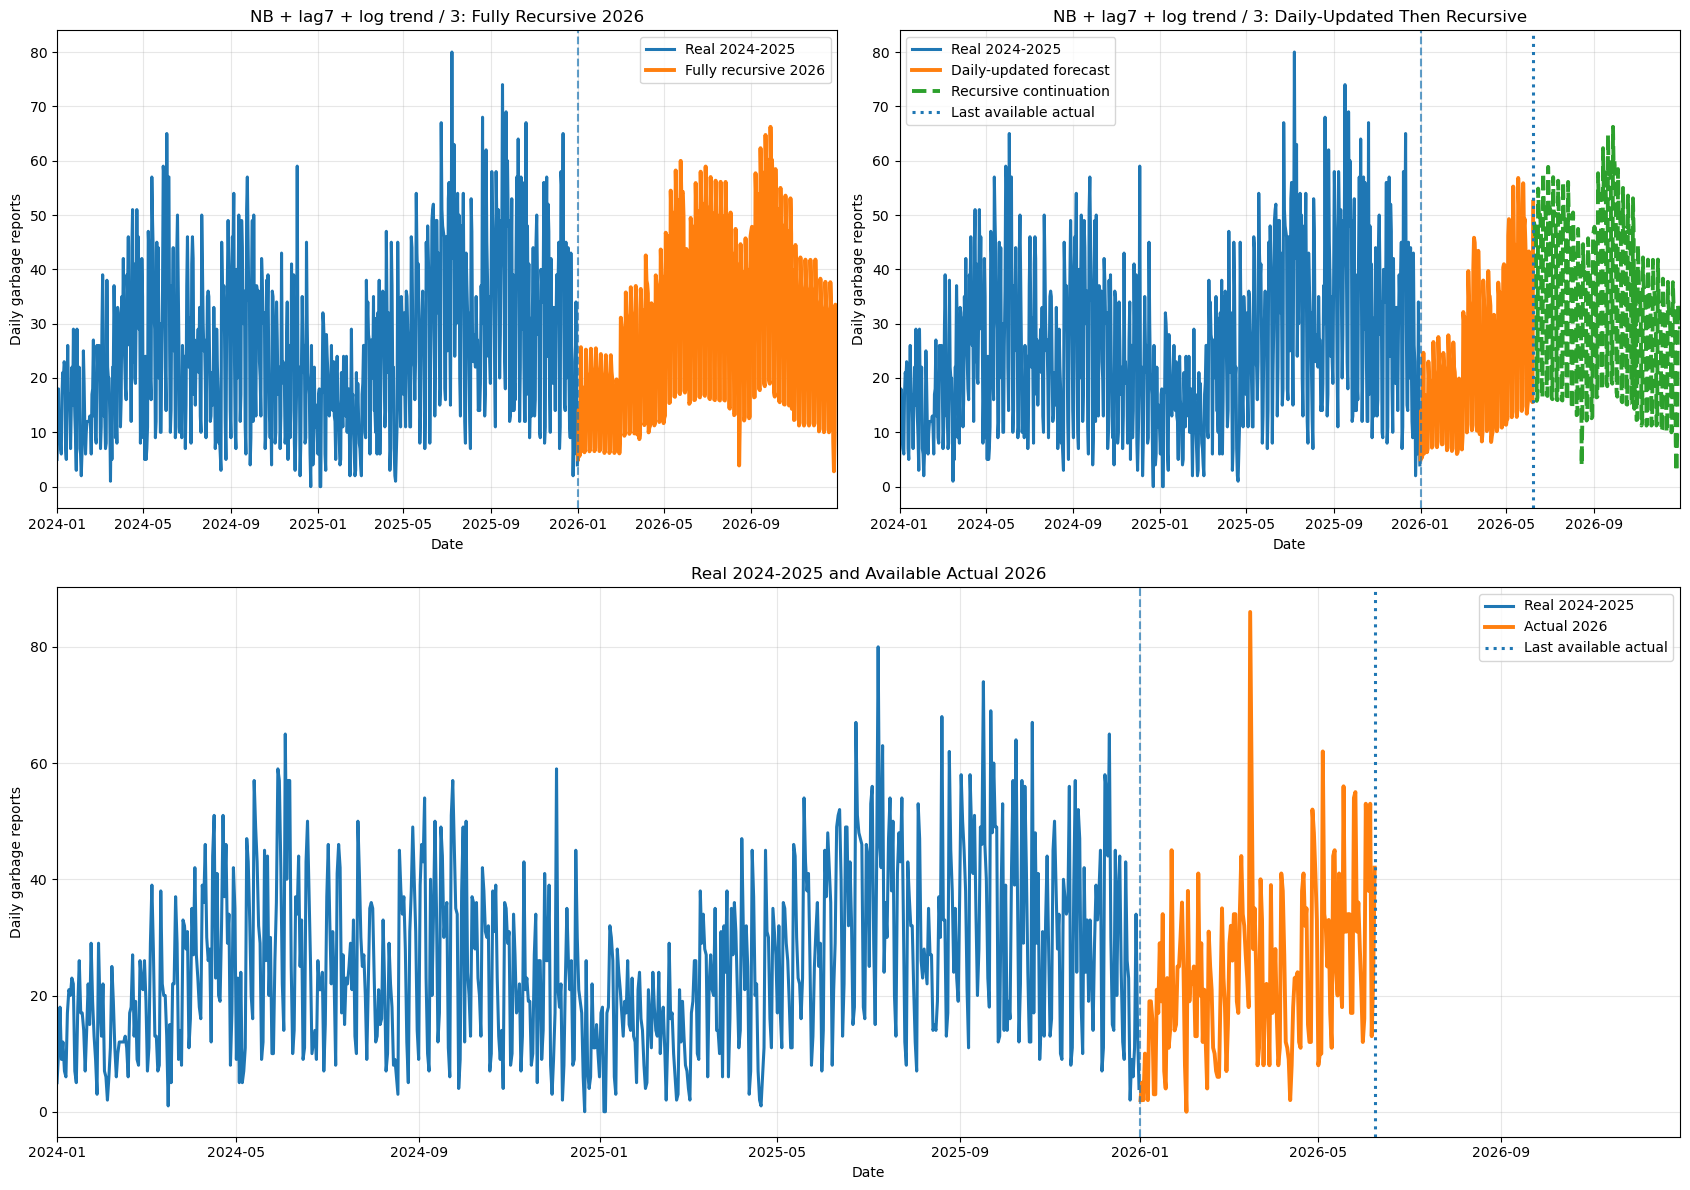

In [3]:
fig = plt.figure(figsize=(17, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Fully recursive
ax1.plot(
    history_plot["reported"], history_plot["reports"],
    linewidth=HISTORY_LINEWIDTH, label=f"Real {HISTORY_PLOT_START_YEAR}-2025"
)
ax1.plot(
    fully_recursive["reported"], fully_recursive["predicted"],
    linewidth=FORECAST_LINEWIDTH, label=f"Fully recursive {FORECAST_YEAR}"
)
ax1.axvline(pd.Timestamp(f"{FORECAST_YEAR}-01-01"), linestyle="--", alpha=0.7)
ax1.set_title(
    f"NB + lag7 + log trend / {LOG_TREND_DIVISOR}: Fully Recursive {FORECAST_YEAR}"
)
ax1.set_ylabel("Daily garbage reports")
ax1.set_xlabel("Date")
ax1.legend()
ax1.grid(alpha=0.3)

# Daily-updated then recursive
ax2.plot(
    history_plot["reported"], history_plot["reports"],
    linewidth=HISTORY_LINEWIDTH, label=f"Real {HISTORY_PLOT_START_YEAR}-2025"
)
ax2.plot(
    daily_updated["reported"], daily_updated["predicted"],
    linewidth=FORECAST_LINEWIDTH, label="Daily-updated forecast"
)
ax2.plot(
    recursive_future["reported"], recursive_future["predicted"],
    linewidth=FORECAST_LINEWIDTH, linestyle="--", label="Recursive continuation"
)
ax2.axvline(pd.Timestamp(f"{FORECAST_YEAR}-01-01"), linestyle="--", alpha=0.7)
ax2.axvline(last_actual, linestyle=":", linewidth=2.2, label="Last available actual")
ax2.set_title(
    f"NB + lag7 + log trend / {LOG_TREND_DIVISOR}: Daily-Updated Then Recursive"
)
ax2.set_ylabel("Daily garbage reports")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(alpha=0.3)

# Actuals
ax3.plot(
    history_plot["reported"], history_plot["reports"],
    linewidth=HISTORY_LINEWIDTH, label=f"Real {HISTORY_PLOT_START_YEAR}-2025"
)
ax3.plot(
    actual_2026["reported"], actual_2026["reports"],
    linewidth=FORECAST_LINEWIDTH, label=f"Actual {FORECAST_YEAR}"
)
ax3.axvline(pd.Timestamp(f"{FORECAST_YEAR}-01-01"), linestyle="--", alpha=0.7)
ax3.axvline(last_actual, linestyle=":", linewidth=2.2, label="Last available actual")
ax3.set_title(f"Real {HISTORY_PLOT_START_YEAR}-2025 and Available Actual {FORECAST_YEAR}")
ax3.set_ylabel("Daily garbage reports")
ax3.set_xlabel("Date")
ax3.legend()
ax3.grid(alpha=0.3)

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(
        pd.Timestamp(f"{HISTORY_PLOT_START_YEAR}-01-01"),
        pd.Timestamp(FORECAST_END),
    )

plt.tight_layout()
plt.show()

## 4. Forecast totals

In [4]:
print(f"Fully recursive {FORECAST_YEAR}: {fully_recursive['predicted'].sum():,.1f}")
print(
    f"Daily-updated + recursive {FORECAST_YEAR}: "
    f"{hybrid_full['predicted'].sum():,.1f}"
)

Fully recursive 2026: 11,268.8
Daily-updated + recursive 2026: 11,191.5
